# Merging Weather and Load data

In [165]:
import os
import pandas as pd

folder_path = '/Users/will/Documents/Beacon MVP/Projects/IESO Data Set Up/output_data'
temp_folder = '/Users/will/Documents/Beacon MVP/Projects/IESO Data Set Up/temp_files/'
output_folder = '/Users/will/Documents/Beacon MVP/Projects/IESO Data Set Up/output_data'

In [166]:
load_df = pd.read_csv(os.path.join(folder_path, 'load_data.csv'))
weather_df = pd.read_csv(os.path.join(temp_folder, 'weather_data_clean.csv'),dtype={'Climate ID': str})
#weather_df = weather_df.drop(columns=["Unnamed: 0"])
mapping_df = pd.read_csv('/Users/will/Documents/Beacon MVP/Projects/IESO Data Set Up/output_data/remaining_fsa_central_weather_station_mapping.csv')
#mapping_df = mapping_df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"])



# Check each DF

In [167]:
no_fsa_load = load_df.FSA.nunique()
no_fsa_map = mapping_df.FSA.nunique()

print(f'There is a mismatch between FSAs in load_df ({no_fsa_load}) and the mapping file ({no_fsa_map})')

# This might be due to weird assigning of FSA to Ontario in IESO data (maybe around Ottawa) 
# I checked original FSA shape file only has 520 FSAs in Ontario so nothing has been lost in preprocessing
# For MVP stick to lower number in FSA Mapping file 

There is a mismatch between FSAs in load_df (563) and the mapping file (520)


In [168]:
weather_uniq_id = weather_df['Climate ID'].nunique()
#load_uniq_id = load_df['Climate ID'].nunique()
mapping_uniq_id = mapping_df['Climate ID'].nunique()

count = weather_df['Climate ID'].isin(mapping_df['Climate ID']).sum()
rows_weather_df = len(weather_df)
print(f'Total rows in weather_df {rows_weather_df}')
print(f"Rows in weather_df with matching IDs in mapping_df: {count}")
print(f'no of unique Climate IDs in weather df: {weather_uniq_id}')
#print(f'no of unique Climate IDs in load df: {load_uniq_id}')
print(f'no of unique Climate IDs in mapping df: {mapping_uniq_id}')
print('All weather data is assocaited with an appropriate Climate ID')

Total rows in weather_df 894744
Rows in weather_df with matching IDs in mapping_df: 894744
no of unique Climate IDs in weather df: 51
no of unique Climate IDs in mapping df: 51
All weather data is assocaited with an appropriate Climate ID


In [169]:
#Check for NaN values

nan_count = weather_df['Temp (C)'].isna().sum()
print(f"NaN count in 'Temp (C)': {nan_count}")

# No NaNs so Preprocessing OK

NaN count in 'Temp (C)': 0


# Convert to same timezone 

In [170]:
# load_df already comes in timezone aware in Americas/Toronto timezone but need to convert to datetime type
# 1. Parse all timestamps as UTC — this avoids the mixed tz issue
load_df['datetime_et'] = pd.to_datetime(load_df['datetime_et'], utc=True)

# 2. Convert to the correct local timezone (DST-aware)
load_df['datetime_et'] = load_df['datetime_et'].dt.tz_convert(ZoneInfo('America/Toronto'))


In [171]:
type(load_df['datetime_et'])

pandas.core.series.Series

In [172]:
load_df.head()

,datetime_et,FSA,TOTAL_CONSUMPTION
0,2023-01-01 00:00:00-05:00,K0A,59932.8
1,2023-01-01 00:00:00-05:00,K0B,14766.3
2,2023-01-01 00:00:00-05:00,K0C,29153.0
3,2023-01-01 00:00:00-05:00,K0E,21944.6
4,2023-01-01 00:00:00-05:00,K0G,24187.8


In [173]:
weather_df.head()

,Date/Time (LST),Climate ID,Temp (C)
0,2023-01-01 00:00,6117700,1.1
1,2023-01-01 01:00,6117700,0.7
2,2023-01-01 02:00,6117700,0.8
3,2023-01-01 03:00,6117700,0.3
4,2023-01-01 04:00,6117700,0.2


In [174]:
from zoneinfo import ZoneInfo
import pandas as pd

# create datetime column
weather_df['datetime'] = pd.to_datetime(weather_df['Date/Time (LST)'])

# IESO data is in LST so Convert LST (UTC-5) to UTC
weather_df['datetime_utc'] = weather_df['datetime'] + pd.Timedelta(hours=5)

# Convert UTC to local time with DST awareness
weather_df['datetime_et'] = weather_df['datetime_utc'].dt.tz_localize('UTC').dt.tz_convert(ZoneInfo('America/Toronto'))


In [175]:
weather_df.tail()

,Date/Time (LST),Climate ID,Temp (C),datetime,datetime_utc,datetime_et
894739,2024-12-31 19:00,6068145,-0.5,2024-12-31 19:00:00,2025-01-01 00:00:00,2024-12-31 19:00:00-05:00
894740,2024-12-31 20:00,6068145,-0.3,2024-12-31 20:00:00,2025-01-01 01:00:00,2024-12-31 20:00:00-05:00
894741,2024-12-31 21:00,6068145,-0.6,2024-12-31 21:00:00,2025-01-01 02:00:00,2024-12-31 21:00:00-05:00
894742,2024-12-31 22:00,6068145,-0.6,2024-12-31 22:00:00,2025-01-01 03:00:00,2024-12-31 22:00:00-05:00
894743,2024-12-31 23:00,6068145,-0.7,2024-12-31 23:00:00,2025-01-01 04:00:00,2024-12-31 23:00:00-05:00


# Merge Dataframes

In [176]:
merged_df = pd.merge(
    load_df,
    mapping_df.drop('Station ID',axis=1),
    on=["FSA"],    
    how="left"
)

In [177]:
print(load_df['datetime_et'].dt.tz)

America/Toronto


In [178]:
print(weather_df['datetime_et'].dt.tz)

America/Toronto


In [179]:
weather_df.tail()

,Date/Time (LST),Climate ID,Temp (C),datetime,datetime_utc,datetime_et
894739,2024-12-31 19:00,6068145,-0.5,2024-12-31 19:00:00,2025-01-01 00:00:00,2024-12-31 19:00:00-05:00
894740,2024-12-31 20:00,6068145,-0.3,2024-12-31 20:00:00,2025-01-01 01:00:00,2024-12-31 20:00:00-05:00
894741,2024-12-31 21:00,6068145,-0.6,2024-12-31 21:00:00,2025-01-01 02:00:00,2024-12-31 21:00:00-05:00
894742,2024-12-31 22:00,6068145,-0.6,2024-12-31 22:00:00,2025-01-01 03:00:00,2024-12-31 22:00:00-05:00
894743,2024-12-31 23:00,6068145,-0.7,2024-12-31 23:00:00,2025-01-01 04:00:00,2024-12-31 23:00:00-05:00


In [184]:
merged_df2 = pd.merge(
    merged_df,
    weather_df,
    left_on=["datetime_et", "Climate ID"],
    right_on=["datetime_et", "Climate ID"],
    how="left"
)

merged_df2 = merged_df2.drop(['datetime','datetime_utc'],axis=1)

In [185]:
merged_df2.head()

,datetime_et,FSA,TOTAL_CONSUMPTION,Climate ID,Name,Date/Time (LST),Temp (C)
0,2023-01-01 00:00:00-05:00,K0A,59932.8,6105978,OTTAWA CDA RCS,2023-01-01 00:00,2.9
1,2023-01-01 00:00:00-05:00,K0B,14766.3,6105397,MOOSE CREEK WELLS,2023-01-01 00:00,3.5
2,2023-01-01 00:00:00-05:00,K0C,29153.0,6105397,MOOSE CREEK WELLS,2023-01-01 00:00,3.5
3,2023-01-01 00:00:00-05:00,K0E,21944.6,6103024,GRENADIER ISLAND,2023-01-01 00:00,6.7
4,2023-01-01 00:00:00-05:00,K0G,24187.8,6104027,KEMPTVILLE CS,2023-01-01 00:00,4.3


# Format and Export

In [186]:
merged_df2 = merged_df2.rename(columns={'datetime_et':'datetime','TOTAL_CONSUMPTION':'target'})

In [187]:
merged_df2.head()

,datetime,FSA,target,Climate ID,Name,Date/Time (LST),Temp (C)
0,2023-01-01 00:00:00-05:00,K0A,59932.8,6105978,OTTAWA CDA RCS,2023-01-01 00:00,2.9
1,2023-01-01 00:00:00-05:00,K0B,14766.3,6105397,MOOSE CREEK WELLS,2023-01-01 00:00,3.5
2,2023-01-01 00:00:00-05:00,K0C,29153.0,6105397,MOOSE CREEK WELLS,2023-01-01 00:00,3.5
3,2023-01-01 00:00:00-05:00,K0E,21944.6,6103024,GRENADIER ISLAND,2023-01-01 00:00,6.7
4,2023-01-01 00:00:00-05:00,K0G,24187.8,6104027,KEMPTVILLE CS,2023-01-01 00:00,4.3


# Exploratory analysis 

In [137]:
# Automated exploratory analysis
from ydata_profiling import ProfileReport
import pandas as pd

profile = ProfileReport(merged_df2, title="Merged Data Profile", explorative=True)
profile.to_file("merged_data_report.html")  # or .to_notebook_iframe()


/opt/anaconda3/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Summarize dataset:  20%|▏| 2/10 [00:00<00:00, 12.21it/s, Describe variable: Temp
Export report to file: 100%|█████████████████████| 1/1 [00:00<00:00, 389.88it/s]


<Axes: xlabel='datetime'>

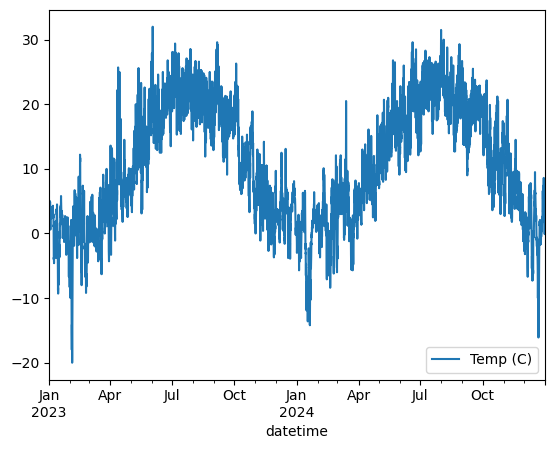

In [188]:
merged_df2[merged_df2['FSA']=='M1T'].plot(x='datetime', y='Temp (C)', kind='line')

<Axes: xlabel='datetime'>

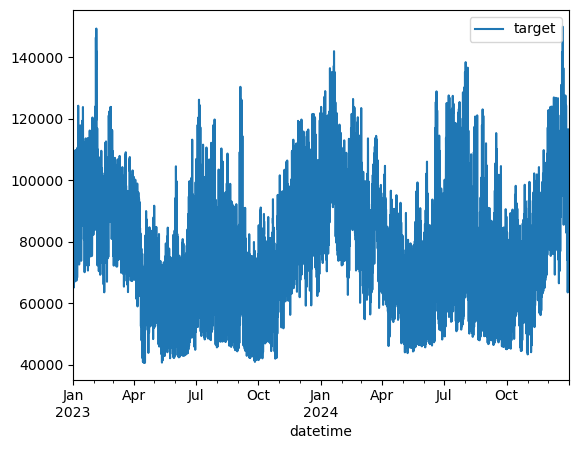

In [189]:
merged_df2[merged_df2['FSA']=='K0K'].plot(x='datetime', y='target', kind='line')

In [157]:
filtered_df = merged_df2[(merged_df2['datetime'].dt.year == 2023) & (merged_df2['datetime'].dt.month == 1)]
filtered_df[filtered_df['FSA']=='M1T'].plot(x='datetime', y='target', kind='line')


AttributeError: 'DataFrame' object has no attribute 'dt'

In [158]:
filtered_df = merged_df2[(merged_df2['datetime'].dt.year == 2024) & (merged_df2['datetime'].dt.month == 1)]
filtered_df[filtered_df['FSA']=='K0K'].plot(x='datetime', y='target', kind='line')
filtered_df[filtered_df['FSA']=='K0K'].head(26)

AttributeError: 'DataFrame' object has no attribute 'dt'

In [1]:
merged_df2.describe()

NameError: name 'merged_df2' is not defined

# Train, Validate, Test Split

In [ ]:
# TRAIN, VALIDATE, TEST SPLIT
output_folder = '/Users/will/Documents/Beacon MVP/Projects/IESO Data Set Up/output_data/'

df_grouped = df_grouped.sort_values("datetime_et")

# Define the split dates based on your 2-year range
start_date = df_grouped["datetime_et"].min()
end_date = df_grouped["datetime_et"].max()

# Define split points
train_end = start_date + pd.DateOffset(months=16)
val_end = train_end + pd.DateOffset(months=4)

# Split the data
train_df = df_grouped[df_grouped["datetime_et"] < train_end]
val_df   = df_grouped[(df_grouped["datetime_et"] >= train_end) & (df_grouped["datetime_et"] < val_end)]
test_df  = df_grouped[df_grouped["datetime_et"] >= val_end]

# Export to CSV
train_df.to_csv(os.path.join(output_folder + "train.csv"), index=False)
val_df.to_csv(os.path.join(output_folder + "validation.csv"), index=False)
test_df.to_csv(os.path.join(output_folder + "test.csv"), index=False)

print("✅ Exported train.csv, validation.csv, and test.csv")